# Phase 2 — Simulation Pipeline

This notebook documents the dataset generation pipeline for the exoplanet transit detection project. The goal is to produce a labelled set of synthetic PLATO-like light curves covering four scenarios:

| Activity/Planet | No planet | Planet |
|---|---|---|
| Mild activity | Class 0 | Class 2 |
| Strong activity | Class 1 | Class 3 |

## Running the simulation

Light curves are generated by `simulation/generate_dataset.py`, which drives the PSLS stellar simulator. Each run samples all parameters from the priors defined below, writes one `.npz` per light curve to `data/lightcurves/`, one YAML config to `data/configs/`, and appends a row to `data/metadata.csv`.

```bash
cd simulation
python generate_dataset.py 1500        # 1500 LCs per class → 6000 total
```

To re-run PSLS for a single existing star ID (config must already exist):

```bash
python run_one.py <star_id>
```

## Building the compressed dataset

After generation, pack all light curves into a single HDF5 file for efficient loading for next phases:

```bash
python build_dataset.py --downsample 12      # 1-min cadence → 5-min (factor 12)
```

This produces `data/dataset.h5` with arrays `flux` (float32, ppm), `time` (days), `labels`, and `file_ids`. The `--downsample` flag averages every N cadences, reducing the array length from ~390 000 to ~32 500 points per light curve.

## This notebook

1. **CESAM2K stellar grid** — inspects the stellar model grid that PSLS snaps to, and shows where our (Teff, log g) sampling window sits.
2. **Parameter sampling** — documents every prior distribution used in the simulation, with the key design choices explained.
4. **Parameter distributions** — histograms of the actual drawn values from `metadata.csv`, confirming the priors are reflected in the dataset.
3. **Sample light curves** — one representative LC per class, to build intuition for what the classifier will see.

In [34]:
# Import standard libraries
import sys
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle

plt.style.use("seaborn-v0_8-deep")

# Resolve project root so we can import simulation utilities and access the grid
PROJECT = Path().resolve().parent

SIM_DIR = PROJECT / "simulation"
DATA_DIR = PROJECT / "data"

from read_dataset import load_dataset, load_metadata

H5_PATH   = DATA_DIR / "dataset.h5"
META_PATH = DATA_DIR / "metadata.csv"

CLASS_LABELS = {0: "Class 0 (quiet, no planet)",
                1: "Class 1 (active, no planet)",
                2: "Class 2 (quiet + planet)",
                3: "Class 3 (active + planet)"}
CLASS_COLORS = {0: "C0", 1: "C1", 2: "C2", 3: "C3"}

## CESAM2K stellar grid

PSLS resolves stellar structure from the CESAM2K main-sequence evolutionary grid (`grid_v0.1_ov0-plato.hdf5`). When a (Teff, log g) pair is sampled, PSLS snaps it to the nearest track using a Chi squared metric; the snapped mass and radius are then used to compute the semi-major axis (Kepler's 3rd law) and the transit depth.

The grid contains ~98 evolutionary tracks spanning a wide range of masses and ages. Below we inspect its coverage and confirm that our sampling window (Teff 5200–6400 K, log g 4.20–4.55, shown in red) sits firmly in the main-sequence regime.

In [35]:
# Load the grid of stellar evolutionary tracks

GRID_PATH = PROJECT / "psls/models/grid_v0.1_ov0-plato.hdf5"

# Load all evolutionary tracks; each track has one entry per age step
grid_rows = []
with h5py.File(GRID_PATH, "r") as f:
    tracks = [k for k in f.keys() if k.startswith("grid_")]
    for track in tracks:
        grp = f[f"{track}/global"]
        chunk = {k: grp[k][:] for k in ("teff", "logg", "mass", "radius", "lum") if k in grp}
        grid_rows.append(pd.DataFrame(chunk))

grid_df = pd.concat(grid_rows, ignore_index=True)
grid_df["mass_msun"]   = grid_df["mass"]   / 1.989e33
grid_df["radius_rsun"] = grid_df["radius"] / 6.957e10

print(f"Grid: {len(tracks)} tracks, {len(grid_df):,} age steps total\n")
print(grid_df[["teff", "logg", "mass_msun", "radius_rsun"]].describe().loc[["min", "max"]].round(3).to_string())

Grid: 97 tracks, 111,289 age steps total

         teff   logg  mass_msun  radius_rsun
min  3973.174  3.388      0.902        0.790
max  6610.955  4.599      1.195        3.528


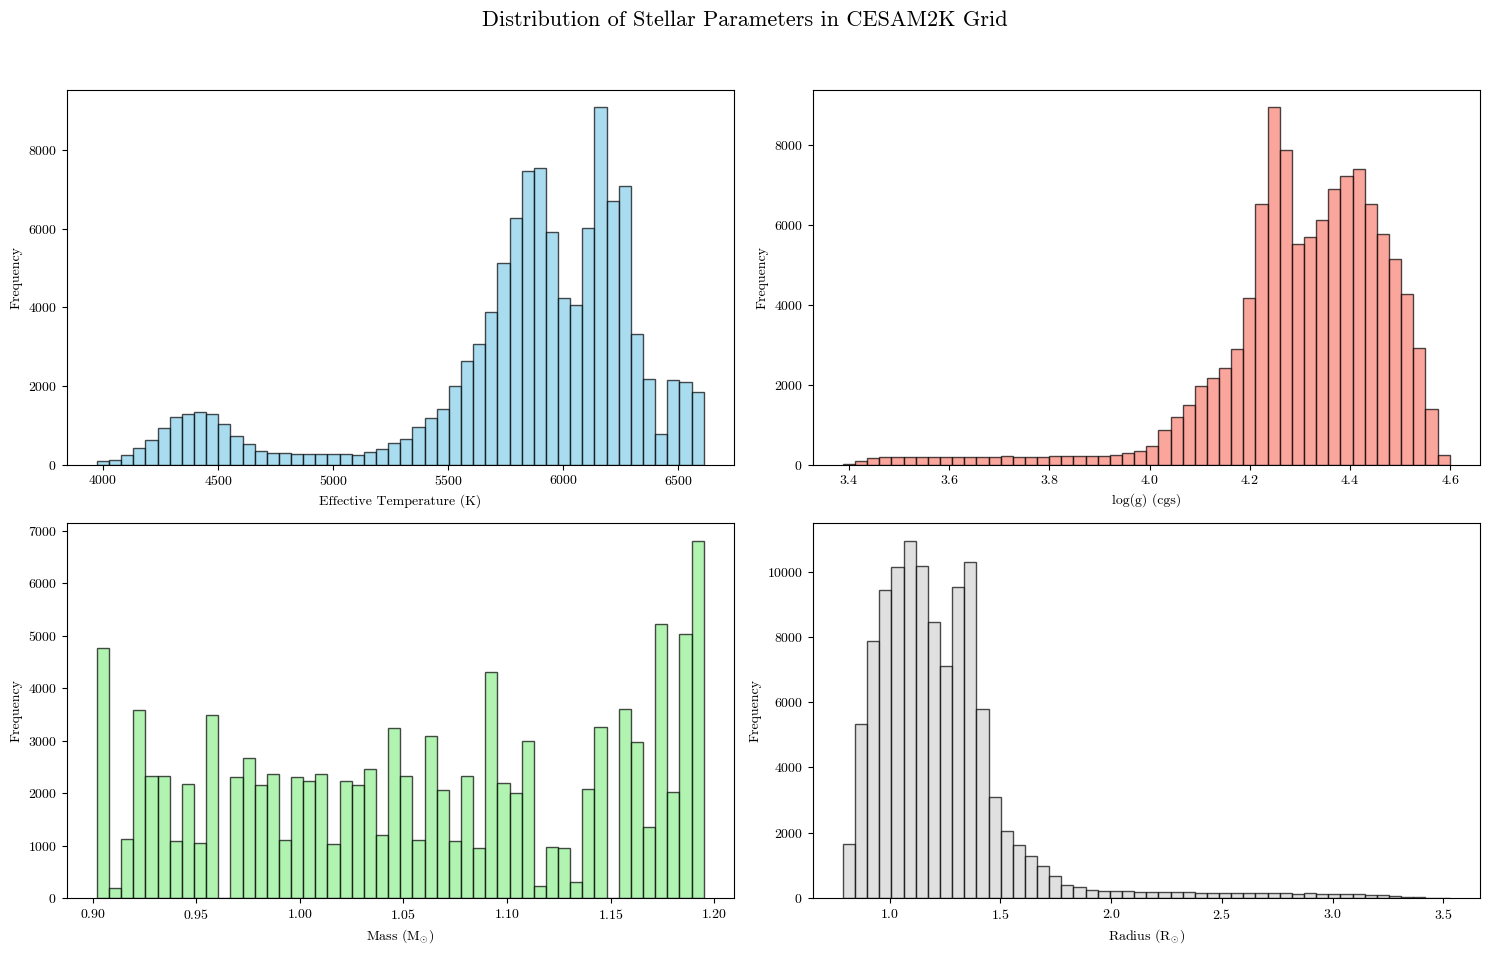

In [36]:
# Display the distribution of stellar parameters in the grid

# Setup the figure
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution of Stellar Parameters in CESAM2K Grid', fontsize=16)

# List of parameters to plot
params = [
('teff', 'Effective Temperature (K)', 'skyblue'),
('logg', 'log(g) (cgs)', 'salmon'),
('mass_msun', r'Mass (M$_{\odot}$)', 'lightgreen'),
('radius_rsun', r'Radius (R$_{\odot}$)', 'lightgrey')
]

for ax, (col, label, color) in zip(axes.flatten(), params):
    if col in grid_df.columns:
        ax.hist(grid_df[col].dropna(), bins=50, color=color, edgecolor='black', alpha=0.7)
        ax.set_xlabel(label)
        ax.set_ylabel('Frequency')
    else:
        ax.set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

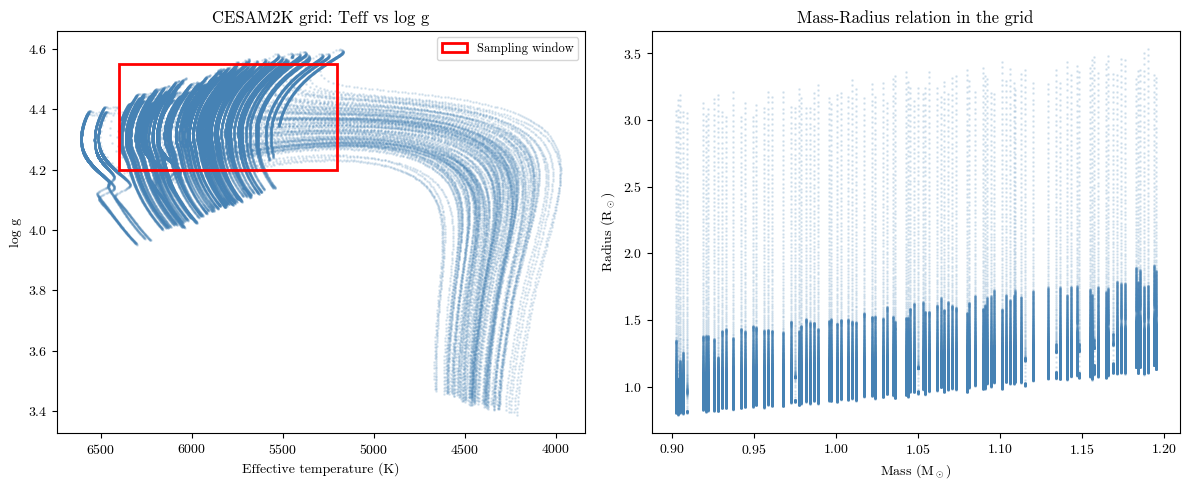


Sampling window: Teff 5200-6400 K,  log g 4.20-4.55


In [37]:
# Now plot the Teff–log g distribution and mass-radius relation

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Teff–log g (HR diagram orientation)
ax = axes[0]
ax.scatter(grid_df["teff"], grid_df["logg"], s=1, alpha=0.15, color="steelblue", rasterized=True)
rect = Rectangle((5200, 4.20), 1200, 0.35,
                 linewidth=2, edgecolor="red", facecolor="none", zorder=3,
                 label="Sampling window")
ax.add_patch(rect)
ax.invert_xaxis()
ax.set_xlabel("Effective temperature (K)")
ax.set_ylabel("log g")
ax.set_title("CESAM2K grid: Teff vs log g")
ax.legend(fontsize=9)

# Right: mass–radius relation
ax = axes[1]
ax.scatter(grid_df["mass_msun"], grid_df["radius_rsun"], s=1, alpha=0.15,
           color="steelblue", rasterized=True)
ax.set_xlabel(r"Mass (M$_\odot$)")
ax.set_ylabel(r"Radius (R$_\odot$)")
ax.set_title("Mass-Radius relation in the grid")

plt.tight_layout()
plt.show()

print("\nSampling window: Teff 5200-6400 K,  log g 4.20-4.55")

## Parameter sampling

Here we explain the priors defined in `generate_dataset.py` and show the histograms of the sampled parameters from `metadata.csv`. Stellar parameters are drawn identically for all classes; activity and planet parameters differ by activity level and class.

### Stellar parameters (every LC)

| Parameter | Distribution | Range |
|---|---|---|
| Teff | uniform | 5200–6400 K |
| Logg | uniform | 4.20–4.55 |

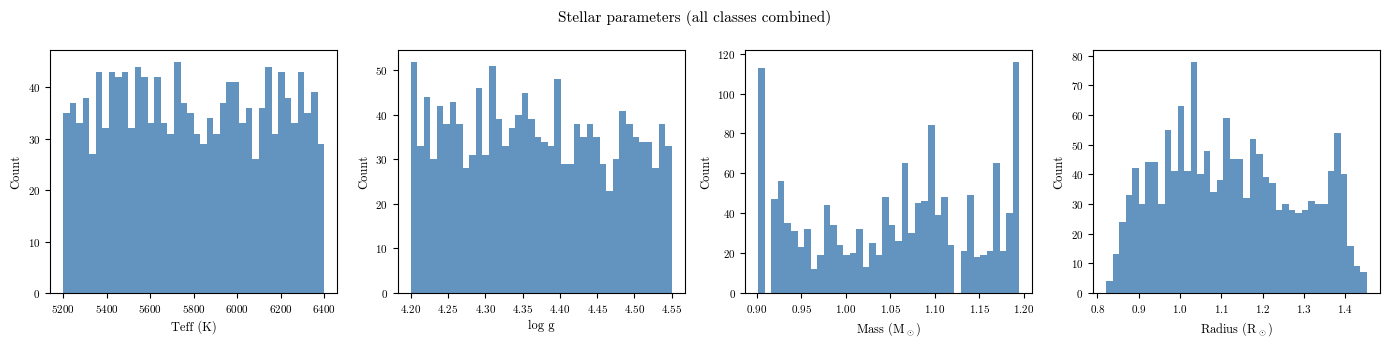

In [38]:
meta = load_metadata(META_PATH)

# Stellar parameters — identical sampling for all classes
stellar_params = [
    ("teff",             "Teff (K)"),
    ("logg",             "log g"),
    ("star_mass_msun",   r"Mass (M$_\odot$)"),
    ("star_radius_rsun", r"Radius (R$_\odot$)"),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, (col, xlabel) in zip(axes, stellar_params):
    ax.hist(meta[col].dropna(), bins=40, color="steelblue", alpha=0.85, edgecolor="none")
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.tick_params(labelsize=8)

fig.suptitle("Stellar parameters (all classes combined)", fontsize=11)
plt.tight_layout()
plt.show()

### Activity parameters (class-dependent)

Two activity levels are defined internally — `mild` (Classes 0 & 2) and `strong` (Classes 1 & 3). Spots and flares are **always enabled** for both levels; the distinction is purely in amplitude and timescale.

| Parameter | mild | strong |
|---|---|---|
| Rotation period [d] | uniform [20, 35] | uniform [8, 22] |
| Activity $\sigma$ [ppm] | log-uniform [5, 40] | log-uniform [25, 150] |
| Activity $\tau$ [d] | uniform [0.5, 2.5] | uniform [1.0, 5.0] |
| Spot count | uniform int [1, 3] | uniform int [2, 5] |
| Spot radius [°] | uniform [0.5, 2.0] | uniform [1.5, 3.0] |
| Spot contrast | uniform [0.62, 0.80] | uniform [0.40, 0.65] |
| Spot lifetime | uniform [0.2, 0.8] × P_rot | uniform [0.5, 1.5] × P_rot |
| Spot latitude [°] | uniform [−20, 20] | uniform [−35, 35] |
| Spot d$\Omega$ | uniform [0.12, 0.25] | uniform [0.05, 0.15] |
| Flare mean period [d] | log-uniform [20, 80] | log-uniform [1, 6] |
| Flare amplitude [ppm] | power-law [15, 100], $\alpha$=2 | power-law [100, 1500], $\alpha$=2 |

Mild and strong distributions **overlap deliberately** on rotation period ([20, 22] d), σ ([25, 40] ppm), spot radius ([1.5, 2.0]°), and spot contrast ([0.62, 0.65]), preventing the classifier from trivially thresholding on any single activity indicator. Spot lifetime is expressed as a fraction of P_rot so coherence (lifetime/P_rot) is preserved independently of the rotation period draw. Flare amplitudes follow a power-law (Davenport 2016); mild-class flares occur every 20–80 days (essentially absent over the 270-day baseline for most draws), while strong-class flares occur every 1–6 days.

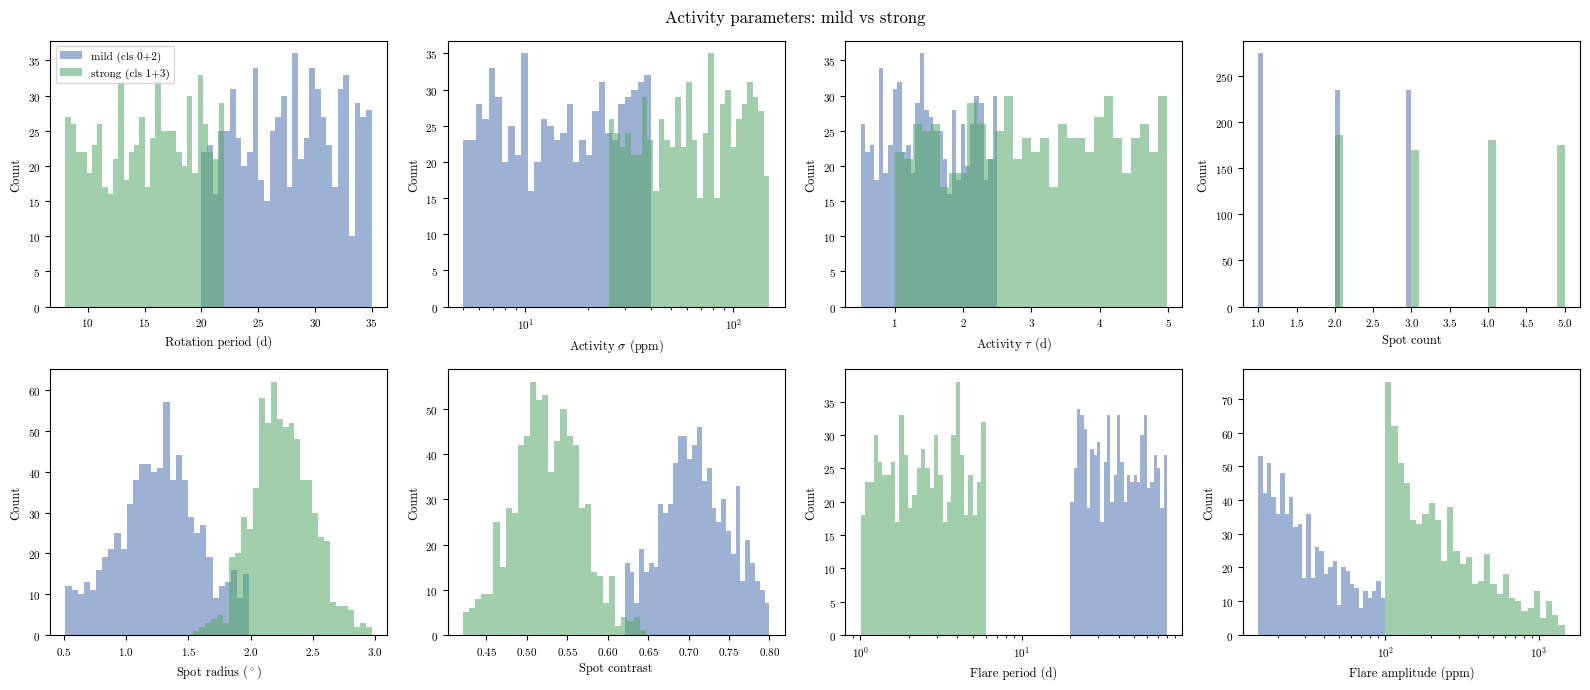

In [47]:
# Activity parameters — mild (classes 0+2) vs strong (classes 1+3)
mild_mask   = meta["activity_class"] == "mild"
strong_mask = meta["activity_class"] == "strong"

activity_params = [
    ("rotation_period_days",   "Rotation period (d)",   False),
    ("sigma_ppm",              r"Activity $\sigma$ (ppm)",      True),
    ("tau_days",               r"Activity $\tau$ (d)",        False),
    ("spot_count",             "Spot count",            False),
    ("spot_radius_deg",        r"Spot radius $(^\circ)$",       False),
    ("spot_contrast",          "Spot contrast",         False),
    ("flare_mean_period_days", "Flare period (d)",      True),
    ("flare_amplitude_ppm",    "Flare amplitude (ppm)", True),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, (col, xlabel, log_x) in zip(axes, activity_params):
    for mask, label, color in [
        (mild_mask,   "mild (cls 0+2)",   "C0"),
        (strong_mask, "strong (cls 1+3)", "C1"),
    ]:
        vals = meta.loc[mask, col].dropna()
        if vals.empty:
            continue
        if log_x:
            lo, hi = np.log10(vals.min()), np.log10(vals.max())
            bins = np.logspace(lo, hi, 30) if lo < hi else 30
            ax.set_xscale("log")
        else:
            bins = 30
        ax.hist(vals, bins=bins, alpha=0.55, color=color, label=label)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.tick_params(labelsize=8)

axes[0].legend(fontsize=8)
fig.suptitle("Activity parameters: mild vs strong", fontsize=12)
plt.tight_layout()
plt.show()

*Note*: The spot parameters are averaged over the group of spots

**Stellar inclination** is not drawn uniformly in degrees. The sampling uses the physically correct geometric prior: uniform in $\cos i$.

For a population of stars with random orientations in 3D space, the probability of observing a star at inclination $i$ is proportional to $\sin i$ — there is far more solid angle near equator-on ($i = 90°$) than near pole-on ($i = 0°$). Sampling uniformly in $\cos i$ reproduces this geometry exactly, since $\mathrm{d}(\cos i) = -\sin i\,\mathrm{d}i$.

The implementation draws from the range $[5°, 90°]$ for all classes:

$$\cos i \;\sim\; \mathcal{U}\!\left(\cos 90°,\;\cos 5°\right) = \mathcal{U}(0,\;0.996)$$

which gives a marginal distribution in degrees of:

$$p(i) \propto \sin i, \qquad i \in [5°, 90°]$$

The histogram of inclination in the dataset therefore rises from near zero at 5° and peaks near 90°. **This is intentional** — a realistically oriented stellar population is dominated by near-equator-on views. For active stars, high inclination means equatorial spots traverse the full projected stellar disc, maximising the amplitude of rotational spot modulation and making the active-star false-positive regime as challenging as possible for the classifier.

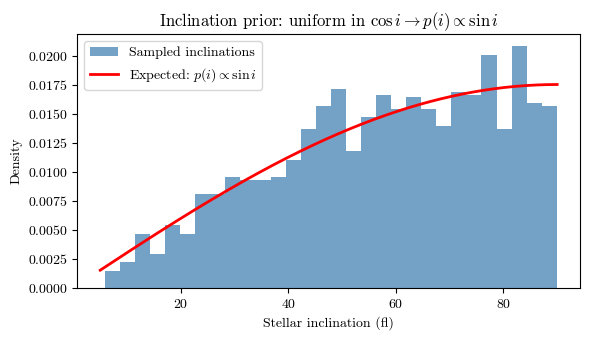

In [40]:
# Inclination histogram vs expected sin(i) prior
fig, ax = plt.subplots(figsize=(6, 3.5))

inc = meta["inclination_deg"].dropna()
counts, edges, _ = ax.hist(
    inc,
    bins=30,
    density=True,
    color="steelblue",
    alpha=0.75,
    label="Sampled inclinations",
)

# Theoretical prior: p(i) ∝ sin(i), normalised over [5°, 90°]
i_deg = np.linspace(5, 90, 300)
i_rad = np.radians(i_deg)
p_i = np.sin(i_rad)
from scipy.integrate import trapezoid
norm = trapezoid(p_i, i_deg)  # normalise so area = 1
ax.plot(i_deg, p_i / norm, "r-", lw=2, label=r"Expected: $p(i)\propto\sin i$")

ax.set_xlabel("Stellar inclination (°)")
ax.set_ylabel("Density")
ax.set_title(r"Inclination prior: uniform in $\cos i \rightarrow p(i)\propto\sin i$")
ax.legend()
plt.tight_layout()
plt.show()

### Planet parameters (Classes 2 & 3)

| Parameter | Distribution | Range |
|---|---|---|
| Orbital period [d] | log-uniform | 3–50 |
| Planet radius [R_Jup] | log-uniform | 0.089–0.356 ($\approx$ 1.0–3.9 $R_{\oplus}$) |
| Semi-major axis [AU] | Kepler's 3rd law | derived from grid stellar mass |
| Orbital angle [°] | uniform | 0–360 |

The log-uniform draws reflect roughly flat occurrence rates in log-period and log-radius; the 3–50 d window ensures at least ~5 transits in the 270-day baseline. The semi-major axis is computed from Kepler's 3rd law using the stellar mass recovered from the CESAM2K grid. Transit depth is likewise computed using the grid stellar radius and stored in `metadata.csv`.

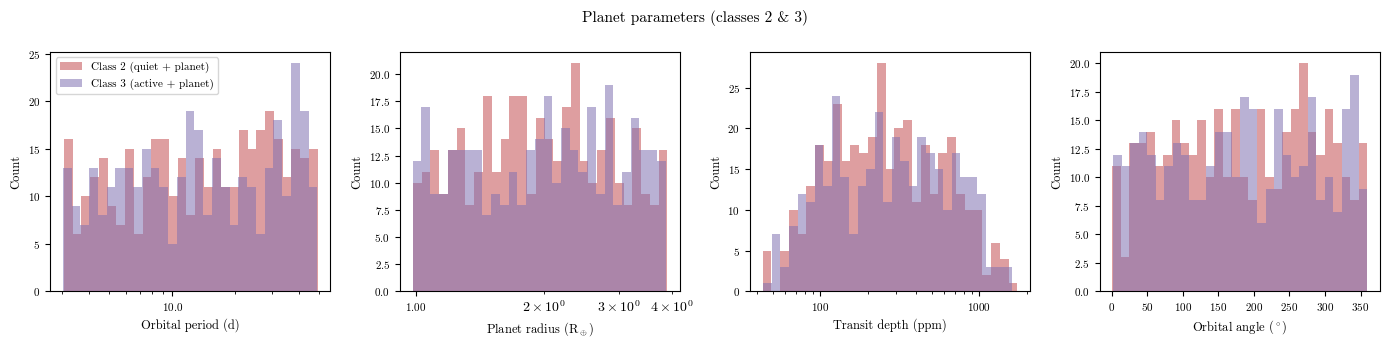

In [46]:
# Planet parameters — classes 2 (quiet + planet) vs 3 (active + planet)
planet_meta = meta[meta["label"].isin([2, 3])].copy()

planet_params = [
    ("planet_period_days",  "Orbital period (d)",          True),
    ("planet_radius_earth", r"Planet radius (R$_\oplus$)", True),
    ("transit_depth_ppm",   "Transit depth (ppm)",         True),
    ("orbital_angle_deg",     r"Orbital angle ($^\circ$)",         False),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

for ax, (col, xlabel, log_x) in zip(axes, planet_params):
    for cls in [2, 3]:
        vals = planet_meta[planet_meta["label"] == cls][col].dropna()
        if vals.empty:
            continue
        if log_x:
            lo, hi = np.log10(vals.min()), np.log10(vals.max())
            bins = np.logspace(lo, hi, 30) if lo < hi else 30
            ax.set_xscale("log")
        else:
            bins = 30
        ax.hist(vals, bins=bins, alpha=0.55, color=CLASS_COLORS[cls], label=CLASS_LABELS[cls])
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.tick_params(labelsize=8)

axes[0].legend(fontsize=8)
fig.suptitle("Planet parameters (classes 2 & 3)", fontsize=11)
plt.tight_layout()
plt.show()

## Sample Light Curves

One representative light curve from each class. For planet classes (2 and 3) a sample with a deeper transit is selected to make the signal visible at this zoom level.

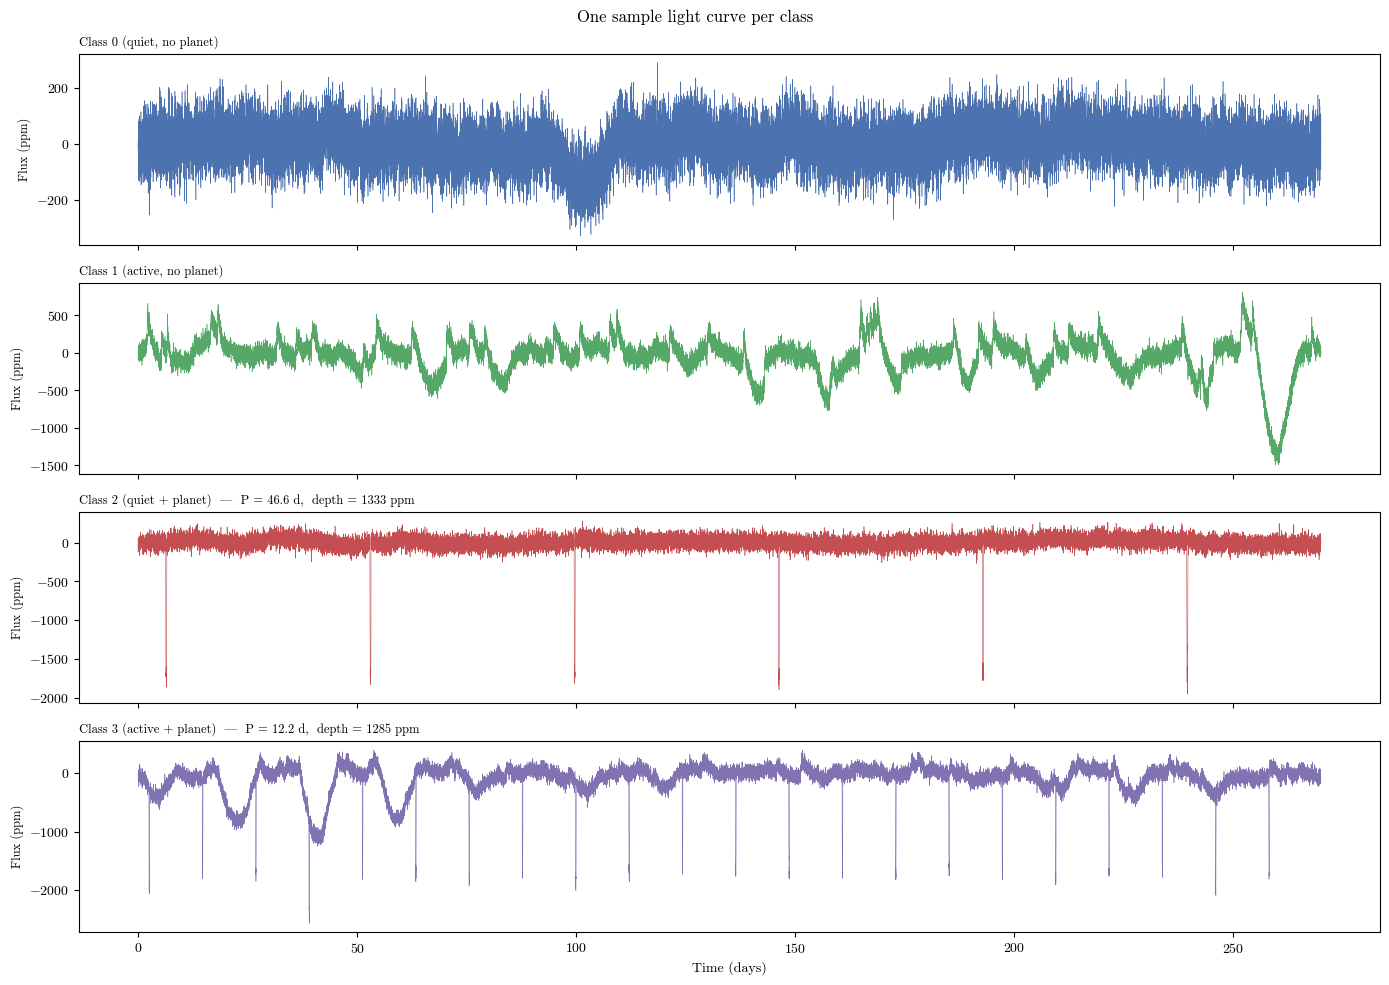

In [ ]:
time_days, flux_all, labels, file_ids = load_dataset(H5_PATH)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

for cls in range(4):
    cls_indices = np.where(labels == cls)[0]

    if cls in (2, 3):
        # Pick a sample with a clearly visible transit (6th-deepest by transit_depth_ppm)
        cls_fids = [file_ids[idx] for idx in cls_indices]
        depth_series = meta[meta.index.isin(cls_fids)]["transit_depth_ppm"].dropna()
        target_fid = depth_series.nlargest(10).index[5]
        picked = next((idx for idx in cls_indices if file_ids[idx] == target_fid), cls_indices[0])
    else:
        picked = cls_indices[0]

    ax = axes[cls]
    ax.plot(time_days, flux_all[picked], lw=0.4, color=CLASS_COLORS[cls], rasterized=True)
    ax.set_ylabel("Flux (ppm)", fontsize=9)

    title = CLASS_LABELS[cls]
    if cls in (2, 3) and file_ids[picked] in meta.index:
        row  = meta.loc[file_ids[picked]]
        depth  = row.get("transit_depth_ppm", float("nan"))
        period = row.get("planet_period_days",  float("nan"))
        title += f"  |  P = {period:.1f} d,  depth = {depth:.0f} ppm"
    ax.set_title(title, fontsize=9, loc="left")

axes[-1].set_xlabel("Time (days)")
fig.suptitle("One sample light curve per class", fontsize=12)
plt.tight_layout()
plt.show()